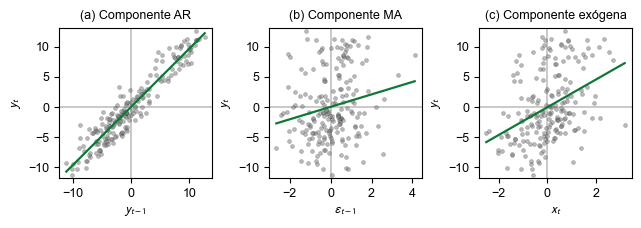

In [2]:

import matplotlib.pyplot as plt
import numpy as np


cm = 1 / 2.54
plt.rcParams.update({
    "font.family": "Arial",
    "mathtext.fontset": "stixsans",
    "font.size": 9,
})

COR_LINHA = "#117738"

# ============================================================
# Simulacao do ARIMAX(1,0,1) com exogena gaussiana
# ============================================================
np.random.seed(2)

T = 200
phi = 0.9        # coef autorregressivo verdadeiro
theta = 0.2      # coef media movel verdadeiro
beta = 1.5       # coef da exogena verdadeiro
sigma = 1.0      # desvio padrao dos residuos

eps = sigma * np.random.randn(T)
x = np.random.randn(T)

y = np.zeros(T)
y[0] = eps[0] + beta * x[0]
for t in range(1, T):
    y[t] = phi * y[t - 1] + theta * eps[t - 1] + beta * x[t] + eps[t]

# Pares para as tres dispersoes
y_t = y[1:]
y_lag = y[:-1]
eps_lag = eps[:-1]
x_t = x[1:]


# ============================================================
# Funcao auxiliar para uma dispersao com linha de regressao
# ============================================================
def dispersao(ax, x_data, y_data, label_x):

    # Pontos
    ax.scatter(x_data, y_data, c="gray", s=8, alpha=0.55,
               edgecolors="black", linewidth=0.2, zorder=2)
    
    # Reta de regressao linear simples para guiar o olho
    slope = np.cov(x_data, y_data, ddof=1)[0, 1] / np.var(x_data, ddof=1)
    intercept = y_data.mean() - slope * x_data.mean()
    xl = np.linspace(x_data.min(), x_data.max(), 100)
    ax.plot(xl, intercept + slope * xl,
            color=COR_LINHA, linewidth=1.6, zorder=3)
    
    # Eixos
    ax.set_xlabel(label_x)
    ax.set_ylabel(r"$y_t$")

    # Linha do zero para referencia
    ax.axhline(0, color="black", linewidth=0.3, zorder=1)
    ax.axvline(0, color="black", linewidth=0.3, zorder=1)


# ============================================================
# Figura com tres paineis horizontais
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16 * cm, 5.5 * cm),
                          layout="constrained")

dispersao(axes[0], y_lag, y_t, r"$y_{t-1}$")
dispersao(axes[1], eps_lag, y_t, r"$\varepsilon_{t-1}$")
dispersao(axes[2], x_t, y_t, r"$x_t$")

axes[0].set_title("(a) Componente AR", fontsize=9)
axes[1].set_title("(b) Componente MA", fontsize=9)
axes[2].set_title("(c) Componente exógena", fontsize=9)

# Unificar o limite vertical em todos os paineis
y_min = y_t.min() - 0.5
y_max = y_t.max() + 0.5
for ax in axes:
    ax.set_ylim(y_min, y_max)


plt.savefig("figuras/exemplo_arimax.png", dpi=300)